<a href="https://colab.research.google.com/github/proshenjitbarua06-dot/skill-morph/blob/main/Multi_Model_Ensemble_Framework_for_Precise_Multi_Class_Epileptic_Seizure_Subtype_Classification_using_High_Resolution_EEG_Signals_A_Comparative_Study_on_the_Bangalore_EEG_Epilepsy_Dataset_(BEED).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
pip install catboost lightgbm xgboost

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


print("✅ All libraries imported successfully!")
print("CatBoost version:", CatBoostClassifier.__module__)


✅ All libraries imported successfully!
CatBoost version: catboost.core


In [23]:
# ====================== LOAD DATA ======================
df = pd.read_csv("/content/drive/MyDrive/Dataset/BEED_Data.csv")
df.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,y
0,4,7,18,25,28,27,20,10,-10,-18,-20,-16,13,32,12,10,0
1,87,114,120,106,76,54,28,5,-19,-49,-85,-102,-100,-89,-61,-21,0
2,-131,-133,-140,-131,-123,-108,-58,-51,-70,-77,-76,-76,-73,-57,-40,-14,0
3,68,104,73,34,-12,-26,-38,-36,-67,-88,-25,31,18,-4,6,-29,0
4,-67,-90,-97,-94,-86,-71,-43,-11,23,46,58,50,39,19,-9,-41,0


In [24]:
print("Dataset Shape:", df.shape)
print("\nClass Distribution:\n", df['y'].value_counts())


Dataset Shape: (8000, 17)

Class Distribution:
 y
0    2000
1    2000
2    2000
3    2000
Name: count, dtype: int64


In [25]:
# Basic statistics
print("\nBasic Statistics:")
print(df.describe().T)

# Check for missing values
print("\nMissing Values:", df.isnull().sum().sum())



Basic Statistics:
      count      mean        std    min    25%  50%    75%    max
X1   8000.0 -1.490375  36.824213 -281.0  -7.00  0.0   8.00  252.0
X2   8000.0 -2.189375  36.108088 -255.0  -7.00  0.0   8.00  261.0
X3   8000.0 -3.237500  35.802490 -255.0  -7.00 -1.0   5.00  238.0
X4   8000.0 -4.119375  36.285268 -257.0 -10.00 -1.0   7.00  246.0
X5   8000.0 -1.821625  37.621284 -264.0 -10.00  0.0  10.00  249.0
X6   8000.0 -2.311750  36.306006 -277.0  -8.00  0.0   8.00  245.0
X7   8000.0 -3.398125  36.358395 -277.0  -8.00 -1.0   6.00  220.0
X8   8000.0 -3.448625  36.522214 -260.0  -7.00 -1.0   5.00  271.0
X9   8000.0 -1.647875  38.107721 -290.0  -7.00  0.0   8.00  280.0
X10  8000.0 -2.561250  37.540680 -302.0  -8.00  0.0   8.00  251.0
X11  8000.0 -3.524500  37.343938 -276.0  -8.00 -1.0   5.00  262.0
X12  8000.0 -4.782750  37.469582 -306.0 -11.00 -2.0   7.00  283.0
X13  8000.0 -2.164000  38.144075 -288.0 -10.00  0.0  10.00  296.0
X14  8000.0 -2.910875  36.640555 -290.0  -8.00  0.0   9.0

In [26]:
# Separate features and target
X = df.drop('y', axis=1)
y = df['y']

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 75% Train, 10% Validation, 15% Test (Stratified)
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.6, random_state=42, stratify=y_temp
)

print("Train set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Train set: (6000, 16)
Validation set: (800, 16)
Test set: (1200, 16)


In [27]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n{'='*60}")
    print(f"{model_name} Results")
    print(f"{'='*60}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Macro F1 : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

    return model, acc, f1


Logistic Regression Results
Accuracy : 0.4792
Macro F1 : 0.4830

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.55      0.64       300
           1       0.51      0.64      0.57       300
           2       0.39      0.37      0.38       300
           3       0.33      0.36      0.35       300

    accuracy                           0.48      1200
   macro avg       0.50      0.48      0.48      1200
weighted avg       0.50      0.48      0.48      1200



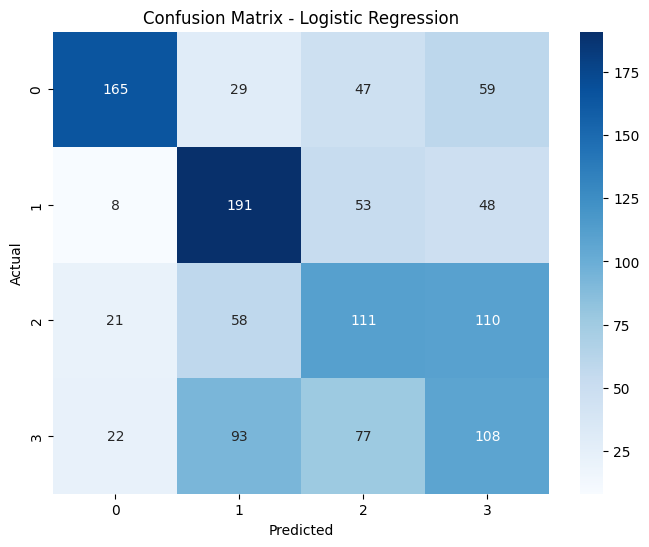


KNN Results
Accuracy : 0.9583
Macro F1 : 0.9585

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       300
           1       0.98      0.93      0.96       300
           2       0.94      0.96      0.95       300
           3       0.91      0.98      0.95       300

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



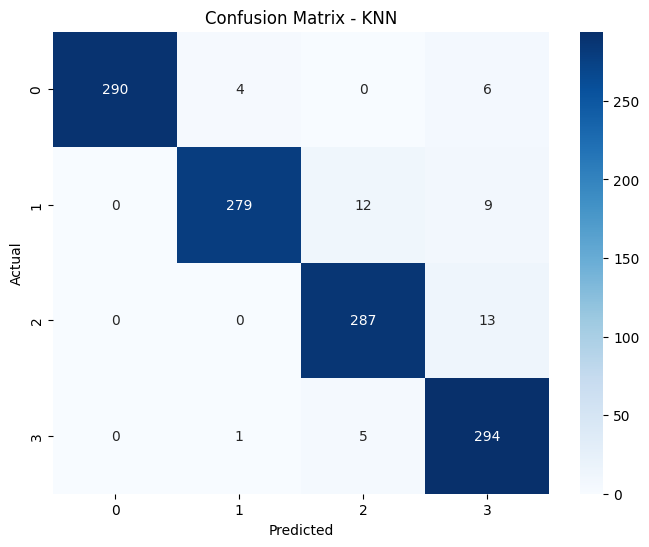


SVM Results
Accuracy : 0.7492
Macro F1 : 0.7323

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       300
           1       0.81      0.75      0.78       300
           2       0.57      0.95      0.71       300
           3       0.75      0.32      0.45       300

    accuracy                           0.75      1200
   macro avg       0.78      0.75      0.73      1200
weighted avg       0.78      0.75      0.73      1200



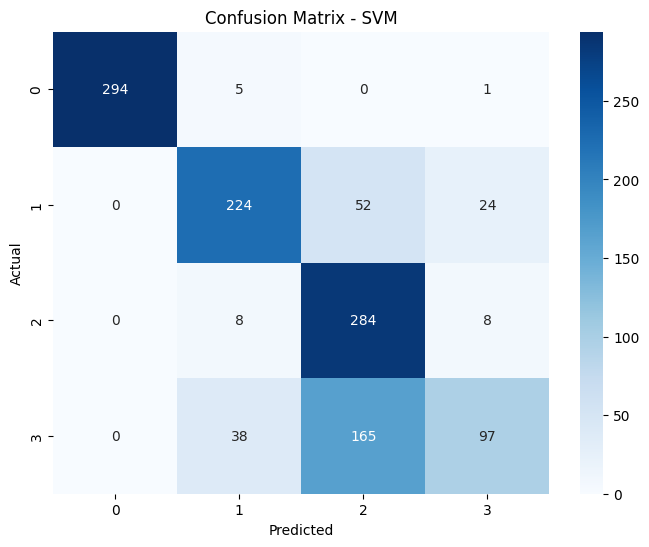


Random Forest Results
Accuracy : 0.9658
Macro F1 : 0.9659

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00       300
           1       0.98      0.97      0.97       300
           2       0.94      0.96      0.95       300
           3       0.94      0.94      0.94       300

    accuracy                           0.97      1200
   macro avg       0.97      0.97      0.97      1200
weighted avg       0.97      0.97      0.97      1200



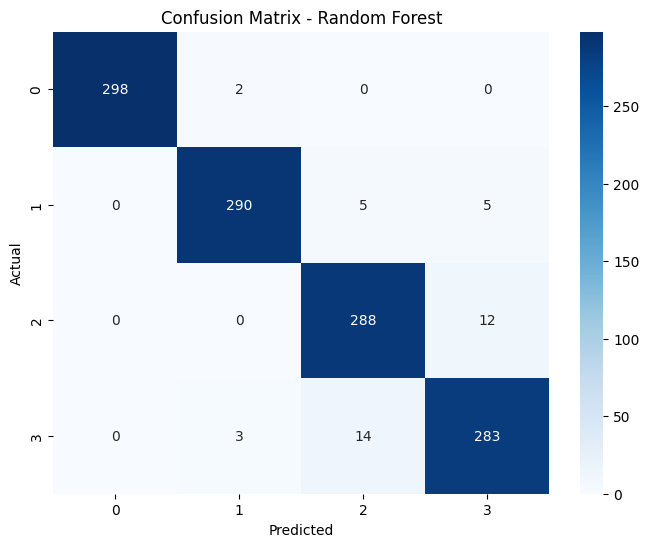


XGBoost Results
Accuracy : 0.9642
Macro F1 : 0.9642

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       300
           1       0.98      0.96      0.97       300
           2       0.95      0.96      0.95       300
           3       0.94      0.94      0.94       300

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



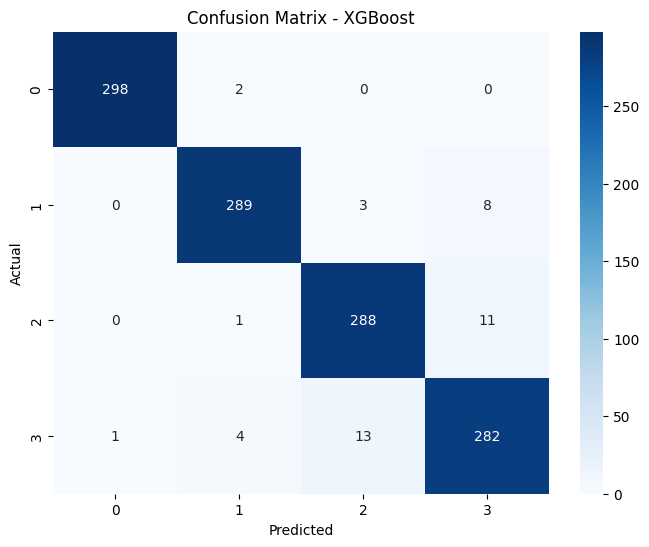


LightGBM Results
Accuracy : 0.9792
Macro F1 : 0.9792

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       1.00      0.97      0.98       300
           2       0.96      0.98      0.97       300
           3       0.96      0.98      0.97       300

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



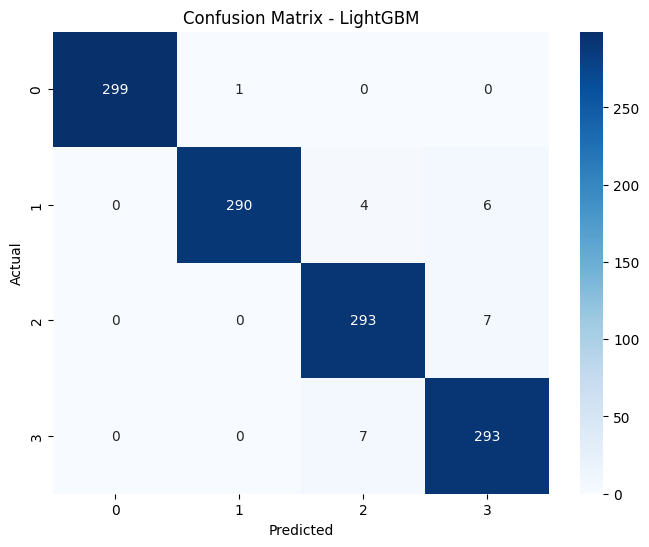


CatBoost Results
Accuracy : 0.9567
Macro F1 : 0.9567

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       0.97      0.95      0.96       300
           2       0.93      0.96      0.94       300
           3       0.93      0.92      0.92       300

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200



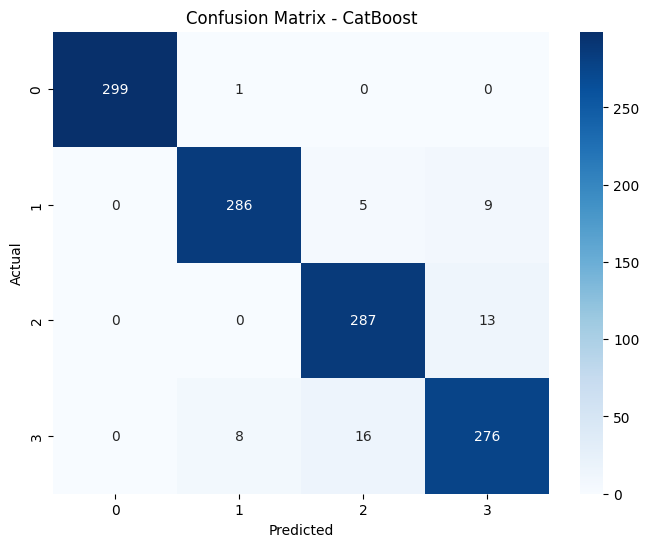


Training Soft Voting Ensemble...

Soft Voting Ensemble Results
Accuracy : 0.9783
Macro F1 : 0.9784

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       300
           1       0.99      0.97      0.98       300
           2       0.96      0.98      0.97       300
           3       0.96      0.97      0.97       300

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



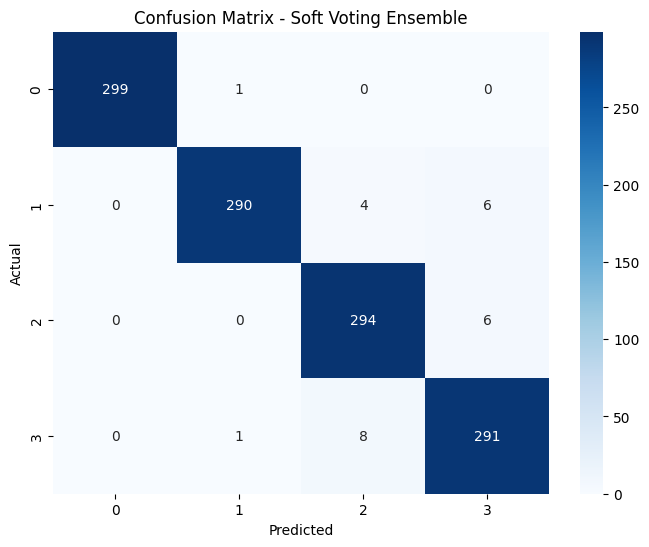

In [29]:
models = {}
results = {}

# 1. Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
models['Logistic Regression'], acc, f1 = evaluate_model(lr, X_train, y_train, X_test, y_test, "Logistic Regression")
results['Logistic Regression'] = (acc, f1)

# 2. KNN
knn = KNeighborsClassifier(n_neighbors=5)
models['KNN'], acc, f1 = evaluate_model(knn, X_train, y_train, X_test, y_test, "KNN")
results['KNN'] = (acc, f1)

# 3. SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42, probability=True)
models['SVM'], acc, f1 = evaluate_model(svm, X_train, y_train, X_test, y_test, "SVM")
results['SVM'] = (acc, f1)

# 4. Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
models['Random Forest'], acc, f1 = evaluate_model(rf, X_train, y_train, X_test, y_test, "Random Forest")
results['Random Forest'] = (acc, f1)

# 5. XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, random_state=42, eval_metric='mlogloss', n_jobs=-1)
models['XGBoost'], acc, f1 = evaluate_model(xgb, X_train, y_train, X_test, y_test, "XGBoost")
results['XGBoost'] = (acc, f1)

# 6. LightGBM
lgbm = LGBMClassifier(n_estimators=300, learning_rate=0.1, random_state=42, verbose=-1)
models['LightGBM'], acc, f1 = evaluate_model(lgbm, X_train, y_train, X_test, y_test, "LightGBM")
results['LightGBM'] = (acc, f1)

# 7. CatBoost
cat = CatBoostClassifier(iterations=300, learning_rate=0.1, depth=6, verbose=False, random_state=42)
models['CatBoost'], acc, f1 = evaluate_model(cat, X_train, y_train, X_test, y_test, "CatBoost")
results['CatBoost'] = (acc, f1)

# Soft Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('LightGBM', models['LightGBM']),
        ('Random Forest', models['Random Forest']),
        ('XGBoost', models['XGBoost'])
    ],
    voting='soft',
    weights=[3, 2, 1]
)

print("\nTraining Soft Voting Ensemble...")
ensemble_model, acc, f1 = evaluate_model(ensemble, X_train, y_train, X_test, y_test, "Soft Voting Ensemble")

In [40]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np
import pandas as pd

SEED = 42

print("Starting 10-Fold Stratified Cross-Validation on All Models...\n")

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

cv_results = {}

for name, model in models.items():
    print(f"Running 10-Fold CV for {name}...")

    f1_scores = cross_val_score(model, X_train, y_train,
                                cv=cv, scoring='f1_macro', n_jobs=-1)

    acc_scores = cross_val_score(model, X_train, y_train,
                                 cv=cv, scoring='accuracy', n_jobs=-1)

    cv_results[name] = {
        'CV_Mean_F1': f1_scores.mean(),
        'CV_Std_F1': f1_scores.std(),
        'CV_Mean_Acc': acc_scores.mean(),
        'CV_Std_Acc': acc_scores.std()
    }

    print(f"   → Macro F1 : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
    print(f"   → Accuracy : {acc_scores.mean():.4f} ± {acc_scores.std():.4f}\n")

# ====================== SOFT VOTING ENSEMBLE CV ======================
print("Running 10-Fold CV for Soft Voting Ensemble...")
f1_ens = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
acc_ens = cross_val_score(ensemble, X_train, y_train, cv=cv, scoring='accuracy', n_jobs=-1)

cv_results['Soft Voting Ensemble'] = {
    'CV_Mean_F1': f1_ens.mean(),
    'CV_Std_F1': f1_ens.std(),
    'CV_Mean_Acc': acc_ens.mean(),
    'CV_Std_Acc': acc_ens.std()
}

print(f"   → Macro F1 : {f1_ens.mean():.4f} ± {f1_ens.std():.4f}")
print(f"   → Accuracy : {acc_ens.mean():.4f} ± {acc_ens.std():.4f}\n")

# ====================== FINAL CV TABLE ======================
cv_df = pd.DataFrame.from_dict(cv_results, orient='index')
cv_df = cv_df.sort_values(by='CV_Mean_F1', ascending=False)

print("\n" + "="*85)
print("FINAL 10-FOLD CROSS-VALIDATION RESULTS")
print("="*85)
print(cv_df.round(4))



print(f"\n🏆 Best Model by CV: {cv_df.index[0]}")

rom sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

print("\n" + "="*90)
print("PER-FOLD CROSS-VALIDATION DETAILS (Accuracy | Macro F1 | ROC AUC)")
print("="*90)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=SEED)

for name, model in list(models.items()) + [('Soft Voting Ensemble', ensemble)]:
    print(f"\n{name}")
    print("-" * 60)

    fold_acc = []
    fold_f1 = []
    fold_auc = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train), 1):
        X_tr, X_val_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]

        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_val_fold)
        y_prob = model.predict_proba(X_val_fold)

        acc = accuracy_score(y_val_fold, y_pred)
        f1 = f1_score(y_val_fold, y_pred, average='macro')

        # ROC AUC (One-vs-Rest)
        y_val_bin = label_binarize(y_val_fold, classes=np.unique(y))
        auc = roc_auc_score(y_val_bin, y_prob, multi_class='ovr', average='macro')

        fold_acc.append(acc)
        fold_f1.append(f1)
        fold_auc.append(auc)

        print(f"Fold {fold:2d} → Acc: {acc:.4f} | Macro F1: {f1:.4f} | ROC AUC: {auc:.4f}")

    print(f"{'-'*60}")
    print(f"Mean     → Acc: {np.mean(fold_acc):.4f} ± {np.std(fold_acc):.4f} | "
          f"Macro F1: {np.mean(fold_f1):.4f} ± {np.std(fold_f1):.4f} | "
          f"ROC AUC: {np.mean(fold_auc):.4f} ± {np.std(fold_auc):.4f}")

Starting 10-Fold Stratified Cross-Validation on All Models...

Running 10-Fold CV for Logistic Regression...
   → Macro F1 : 0.4801 ± 0.0160
   → Accuracy : 0.4750 ± 0.0153

Running 10-Fold CV for KNN...
   → Macro F1 : 0.9480 ± 0.0065
   → Accuracy : 0.9478 ± 0.0065

Running 10-Fold CV for SVM...
   → Macro F1 : 0.7270 ± 0.0146
   → Accuracy : 0.7433 ± 0.0146

Running 10-Fold CV for Random Forest...
   → Macro F1 : 0.9599 ± 0.0087
   → Accuracy : 0.9598 ± 0.0087

Running 10-Fold CV for XGBoost...
   → Macro F1 : 0.9619 ± 0.0033
   → Accuracy : 0.9618 ± 0.0033

Running 10-Fold CV for LightGBM...
   → Macro F1 : 0.9727 ± 0.0041
   → Accuracy : 0.9727 ± 0.0041

Running 10-Fold CV for CatBoost...
   → Macro F1 : 0.9499 ± 0.0050
   → Accuracy : 0.9498 ± 0.0050

Running 10-Fold CV for Soft Voting Ensemble...
   → Macro F1 : 0.9712 ± 0.0037
   → Accuracy : 0.9712 ± 0.0037


FINAL 10-FOLD CROSS-VALIDATION RESULTS
                      CV_Mean_F1  CV_Std_F1  CV_Mean_Acc  CV_Std_Acc
LightGBM   


 Most Important Features (LightGBM):
   Feature  Importance
4       X5        2533
7       X8        2296
5       X6        2263
15     X16        2225
3       X4        2098
6       X7        2089
11     X12        2021
8       X9        2010
10     X11        1969
2       X3        1952
0       X1        1874
12     X13        1825
14     X15        1800
1       X2        1694
13     X14        1678
9      X10        1676


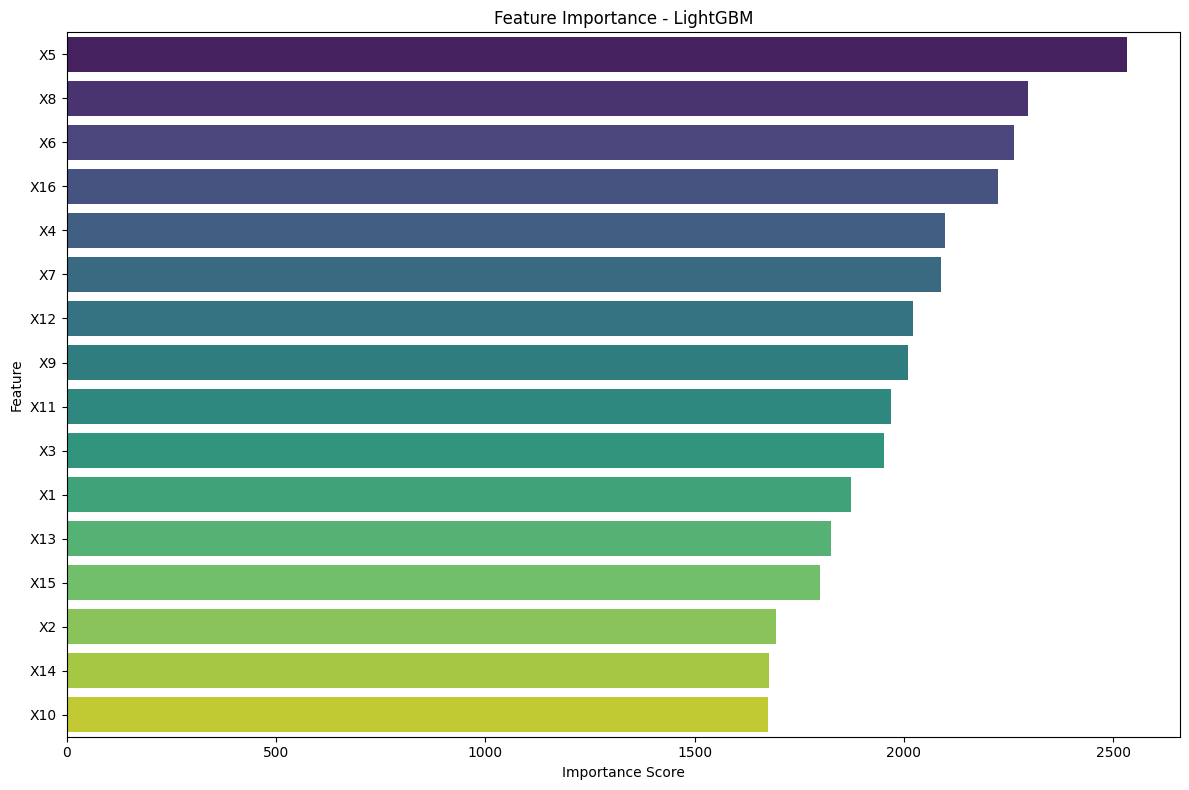

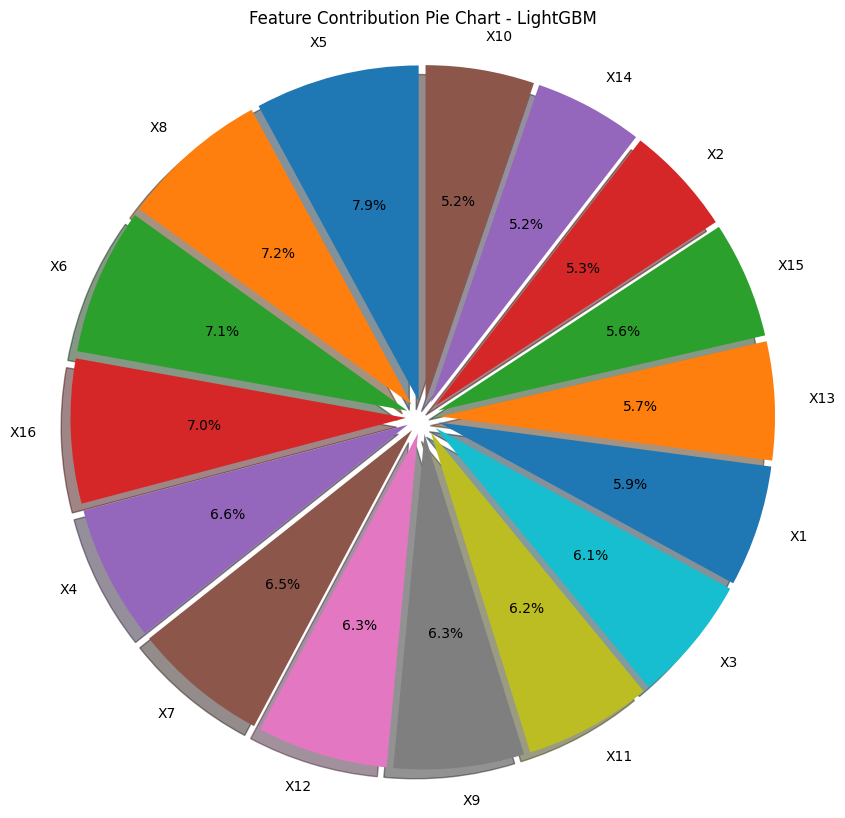

In [41]:
# LightGBM Feature Importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': models['LightGBM'].feature_importances_
}).sort_values('Importance', ascending=False)

print("\n Most Important Features (LightGBM):")
print(feature_importance.head(16))

# Bar Plot
plt.figure(figsize=(12, 8))
sns.barplot(data=feature_importance.head(16), x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance - LightGBM')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

# Pie Chart (Features Contribution)
top15 = feature_importance.head(16)
plt.figure(figsize=(10, 10))
plt.pie(top15['Importance'], labels=top15['Feature'], autopct='%1.1f%%', startangle=90,
        explode=[0.05]*len(top15), shadow=True)
plt.title('Feature Contribution Pie Chart - LightGBM')
plt.axis('equal')
plt.show()

Computing SHAP values for LightGBM (Multi-class)...
Generating SHAP Summary Plots...


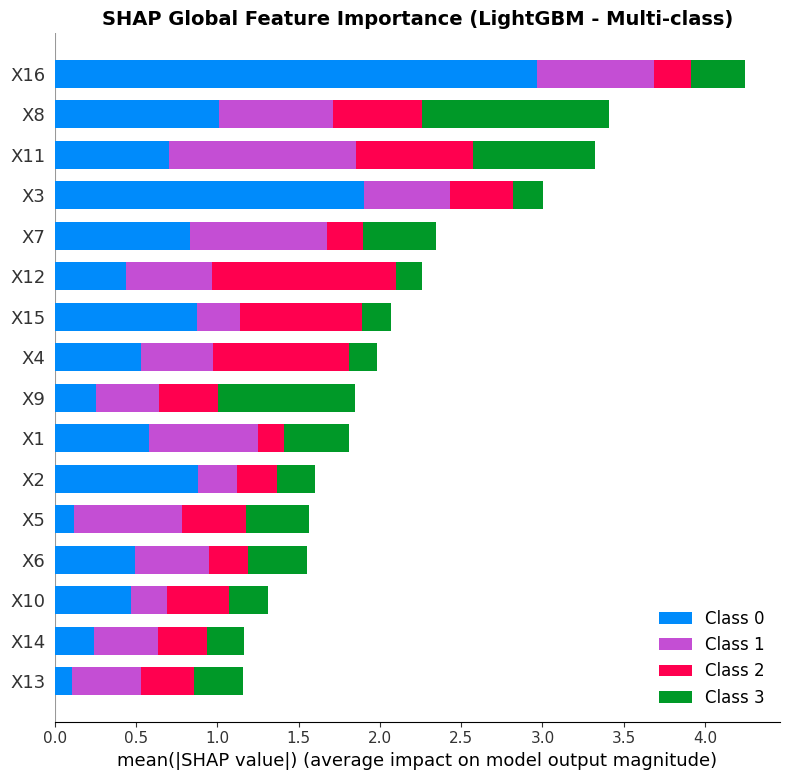

In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Best Model
best_model = models['LightGBM']

print("Computing SHAP values for LightGBM (Multi-class)...")

explainer = shap.TreeExplainer(best_model)

# Use a sample to speed up (increase if you want more accurate results)
X_test_sample = X_test.iloc[:400]   # Adjust based on your RAM/speed

shap_values = explainer.shap_values(X_test_sample)

# ====================== GLOBAL SHAP SUMMARY ======================
print("Generating SHAP Summary Plots...")

# 1. Bar Plot - Overall Feature Importance
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=16, show=False)
plt.title("SHAP Global Feature Importance (LightGBM - Multi-class)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



Class 0: Healthy subjects (Negative class / Control)
Class 1: Generalized epilepsy seizures
Class 2: Focal (partial) epilepsy seizures
Class 3: Seizure-like events (including non-convulsive / behavioral signs)

This is a multi-class classification problem where your models (especially LightGBM) are distinguishing between these four types of EEG patterns with very high accuracy (~97.67%).


Computing SHAP values for detailed analysis...


DETAILED SHAP ANALYSIS FOR CLASS 0: 0 - Healthy (Control)


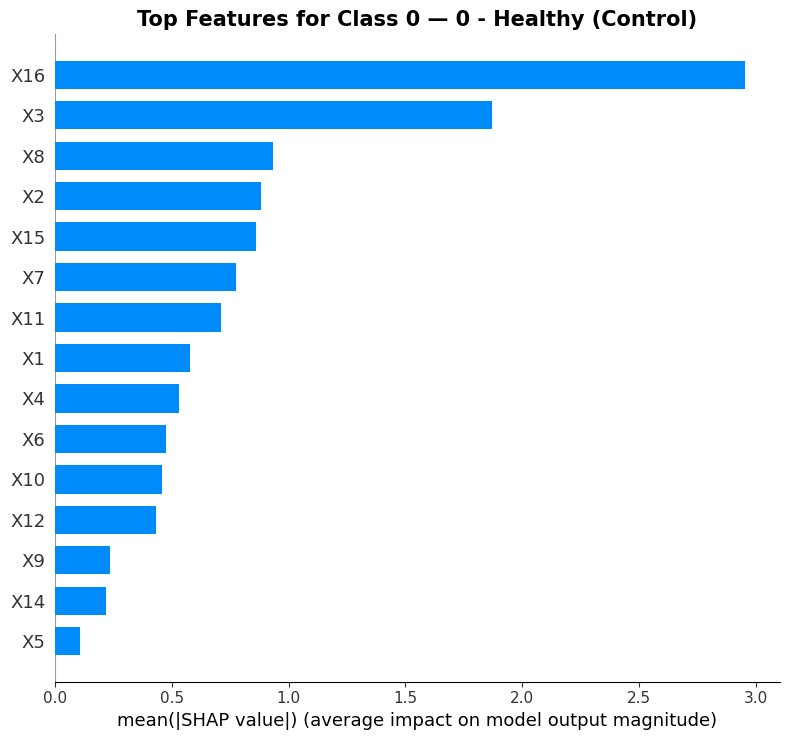


Top  Most Important Features for Class 0 (0 - Healthy (Control)):
   Feature  Mean_Abs_SHAP
0      X16       2.956352
1       X3       1.873119
2       X8       0.934882
3       X2       0.880531
4      X15       0.858556
5       X7       0.775156
6      X11       0.709319
7       X1       0.576229
8       X4       0.532588
9       X6       0.473264
10     X10       0.460260
11     X12       0.434138
12      X9       0.234381
13     X14       0.219279
14      X5       0.106174
15     X13       0.098408

DETAILED SHAP ANALYSIS FOR CLASS 1: 1 - Generalized Seizures


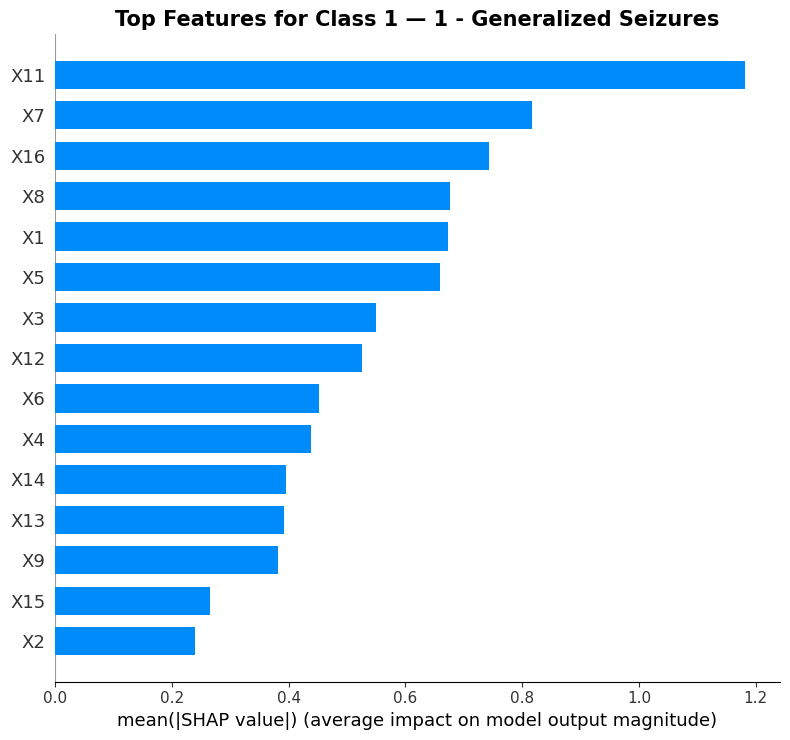


Top  Most Important Features for Class 1 (1 - Generalized Seizures):
   Feature  Mean_Abs_SHAP
0      X11       1.182255
1       X7       0.815984
2      X16       0.742450
3       X8       0.676160
4       X1       0.672075
5       X5       0.659728
6       X3       0.549879
7      X12       0.526309
8       X6       0.451377
9       X4       0.438215
10     X14       0.395767
11     X13       0.392707
12      X9       0.382227
13     X15       0.264748
14      X2       0.239523
15     X10       0.211407

DETAILED SHAP ANALYSIS FOR CLASS 2: 2 - Focal Seizures


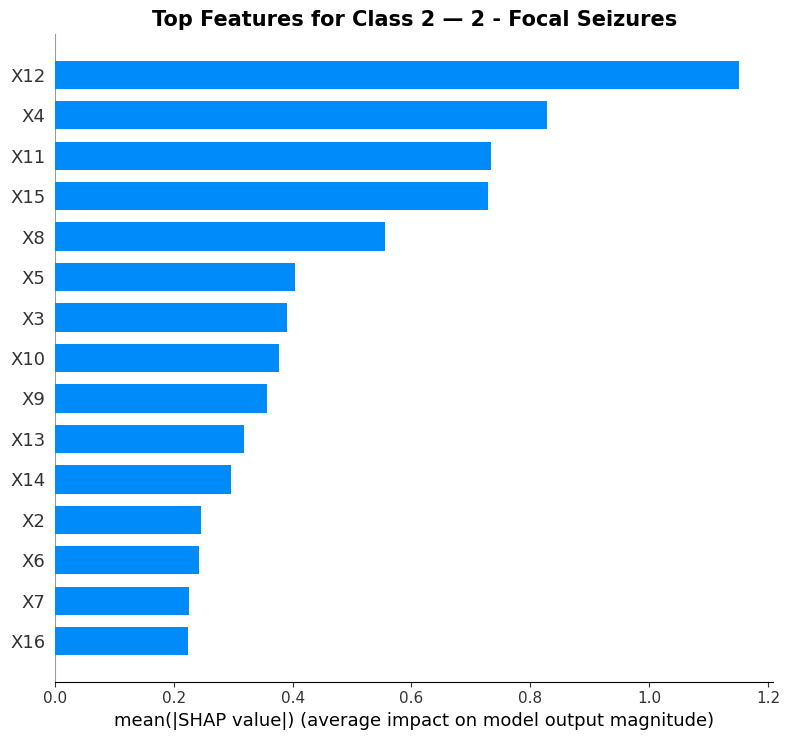


Top  Most Important Features for Class 2 (2 - Focal Seizures):
   Feature  Mean_Abs_SHAP
0      X12       1.151589
1       X4       0.828250
2      X11       0.733602
3      X15       0.729239
4       X8       0.556151
5       X5       0.403240
6       X3       0.390352
7      X10       0.377212
8       X9       0.356588
9      X13       0.318442
10     X14       0.296244
11      X2       0.245360
12      X6       0.242718
13      X7       0.225123
14     X16       0.224641
15      X1       0.158379

DETAILED SHAP ANALYSIS FOR CLASS 3: 3 - Seizure Events (Eye blink, Staring, etc.)


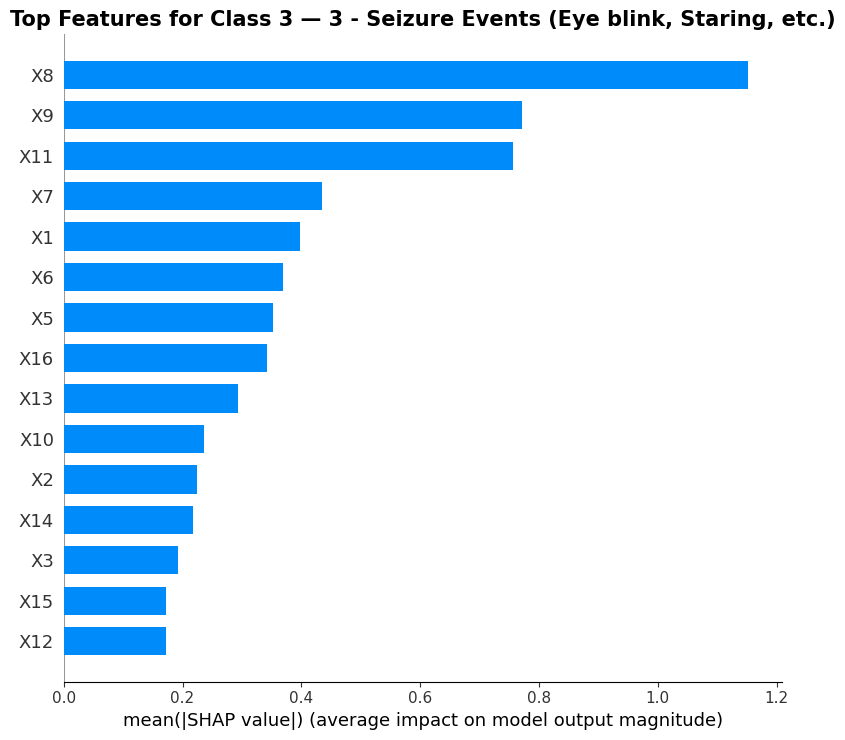


Top  Most Important Features for Class 3 (3 - Seizure Events (Eye blink, Staring, etc.)):
   Feature  Mean_Abs_SHAP
0       X8       1.151264
1       X9       0.771804
2      X11       0.756608
3       X7       0.434402
4       X1       0.397074
5       X6       0.368771
6       X5       0.352213
7      X16       0.342575
8      X13       0.292531
9      X10       0.236077
10      X2       0.223876
11     X14       0.217715
12      X3       0.192449
13     X15       0.172396
14     X12       0.171972
15      X4       0.166931


In [ ]:
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

best_model = models['LightGBM']

class_names = {
    0: "0 - Healthy (Control)",
    1: "1 - Generalized Seizures",
    2: "2 - Focal Seizures",
    3: "3 - Seizure Events (Eye blink, Staring, etc.)"
}

print("Computing SHAP values for detailed analysis...\n")
explainer = shap.TreeExplainer(best_model)

# Sample size (you can increase to 400-500 if your system allows)
X_test_sample = X_test.iloc[:300]

shap_values = explainer.shap_values(X_test_sample)

# ====================== CLASS-WISE SHAP ANALYSIS ======================
for i in range(4):
    print(f"\n{'='*90}")
    print(f"DETAILED SHAP ANALYSIS FOR CLASS {i}: {class_names[i]}")
    print(f"{'='*90}")

    sv = shap_values[i] if isinstance(shap_values, list) else shap_values[:, :, i]

    # 1. Bar Plot - Top Feature Importance
    plt.figure(figsize=(15, 9))
    shap.summary_plot(sv, X_test_sample, plot_type="bar", max_display=15, show=False)
    plt.title(f"Top Features for Class {i} — {class_names[i]}", fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.show()


    # 2. Top Features Table
    class_shap = pd.DataFrame({
        'Feature': X_test.columns,
        'Mean_Abs_SHAP': np.abs(sv).mean(axis=0)
    }).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

    print(f"\nTop  Most Important Features for Class {i} ({class_names[i]}):")
    print(class_shap.head(16))





In [ ]:
!pip install lime -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


LIME Explainer created successfully!

Explaining prediction for Sample Index: 25
True Label: 0 → Healthy


<Figure size 1400x800 with 0 Axes>

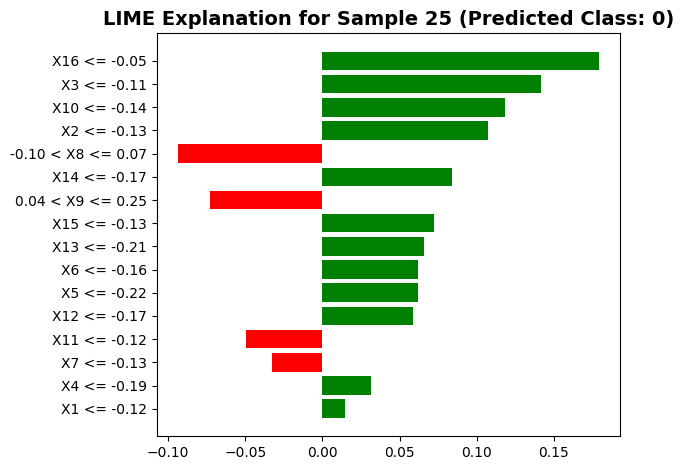


Top Features Contribution (LIME):
               Feature  Contribution
0         X16 <= -0.05      0.179169
1          X3 <= -0.11      0.141720
2         X10 <= -0.14      0.118519
3          X2 <= -0.13      0.107067
4   -0.10 < X8 <= 0.07     -0.093676
5         X14 <= -0.17      0.083866
6    0.04 < X9 <= 0.25     -0.072796
7         X15 <= -0.13      0.072299
8         X13 <= -0.21      0.065636
9          X6 <= -0.16      0.062114
10         X5 <= -0.22      0.061838
11        X12 <= -0.17      0.059002
12        X11 <= -0.12     -0.049429
13         X7 <= -0.13     -0.032899
14         X4 <= -0.19      0.031610
15         X1 <= -0.12      0.014879


In [ ]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# Use the best model
best_model = models['LightGBM']

# Create LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Healthy (0)', 'Generalized (1)', 'Focal (2)', 'Seizure Events (3)'],
    mode='classification',
    discretize_continuous=True
)

print("LIME Explainer created successfully!\n")

# ====================== LIME for a Single Prediction ======================
# Choose a sample from test set (you can change the index)
sample_idx = 25   # Change this to any index between 0 to len(X_test)-1

instance = X_test.iloc[sample_idx:sample_idx+1].values[0]
true_label = y_test.iloc[sample_idx]

print(f"Explaining prediction for Sample Index: {sample_idx}")
print(f"True Label: {true_label} → {['Healthy','Generalized','Focal','Seizure Events'][true_label]}")

# Generate LIME explanation
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=best_model.predict_proba,
    num_features=16,
    labels=[0,1,2,3]
)

# ====================== VISUALIZATIONS ======================

# 1. Main LIME Explanation Plot (Image Output)
plt.figure(figsize=(14, 8))
exp.as_pyplot_figure(label=best_model.predict([instance])[0])
plt.title(f"LIME Explanation for Sample {sample_idx} (Predicted Class: {best_model.predict([instance])[0]})",
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



# 3. Show Top Contributing Features as Table
lime_df = pd.DataFrame(exp.as_list(label=best_model.predict([instance])[0]),
                      columns=['Feature', 'Contribution'])
print("\nTop Features Contribution (LIME):")
print(lime_df)

In [ ]:
# Analyze 5 different samples
for idx in [0, 10, 25, 50, 100]:
    instance = X_test.iloc[idx].values
    true_label = y_test.iloc[idx]
    pred_label = best_model.predict([instance])[0]

    exp = explainer.explain_instance(instance, best_model.predict_proba, num_features=12)

    print(f"Sample {idx} → True: {true_label}, Predicted: {pred_label} → Saved")

Sample 0 → True: 1, Predicted: 1 → Saved
Sample 10 → True: 1, Predicted: 1 → Saved
Sample 25 → True: 0, Predicted: 0 → Saved
Sample 50 → True: 0, Predicted: 0 → Saved
Sample 100 → True: 3, Predicted: 3 → Saved


LIME Explainer Ready!


Sample 0 → True Label: 1 | Predicted: 1


<Figure size 1600x900 with 0 Axes>

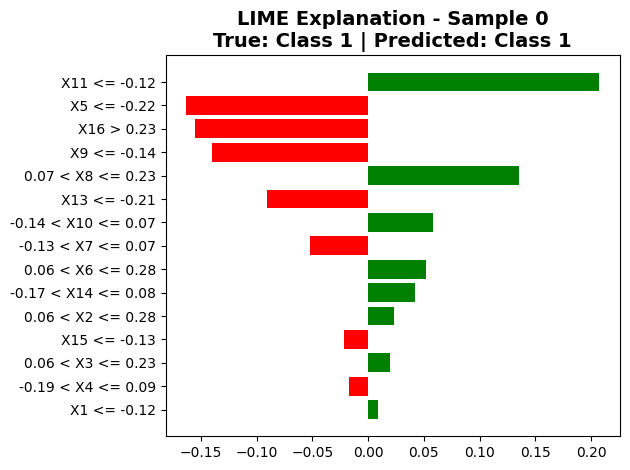

✅ Plot shown + HTML saved as 'lime_explanation_sample_0.html'

Sample 10 → True Label: 1 | Predicted: 1


<Figure size 1600x900 with 0 Axes>

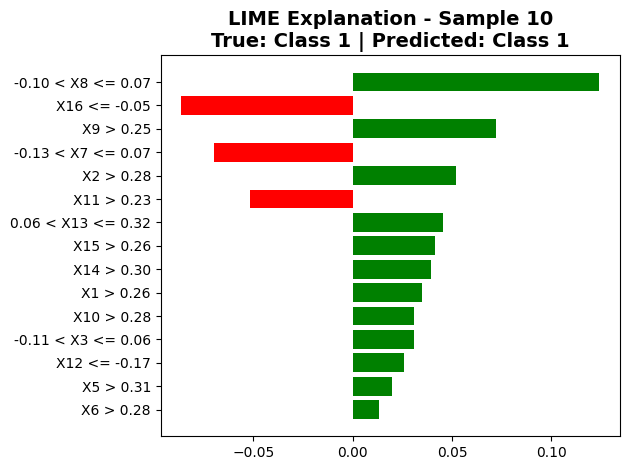

✅ Plot shown + HTML saved as 'lime_explanation_sample_10.html'

Sample 25 → True Label: 0 | Predicted: 0


<Figure size 1600x900 with 0 Axes>

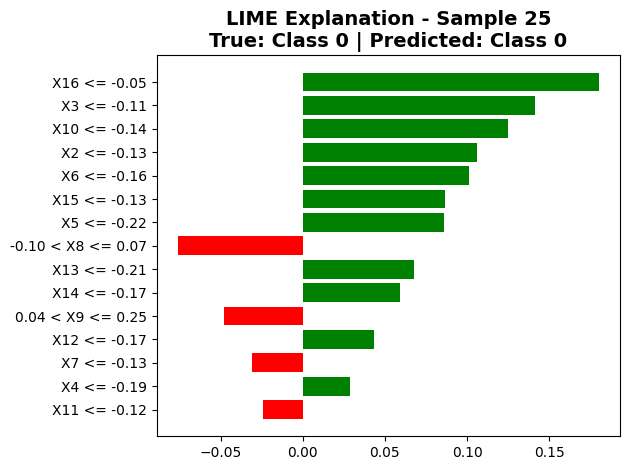

✅ Plot shown + HTML saved as 'lime_explanation_sample_25.html'

Sample 50 → True Label: 0 | Predicted: 0


<Figure size 1600x900 with 0 Axes>

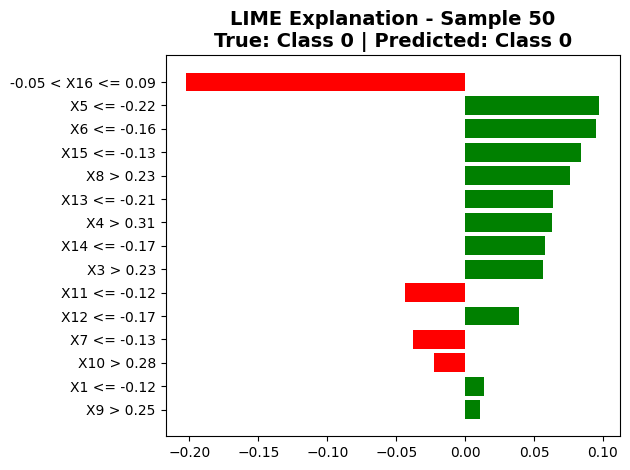

✅ Plot shown + HTML saved as 'lime_explanation_sample_50.html'

Sample 100 → True Label: 3 | Predicted: 3


<Figure size 1600x900 with 0 Axes>

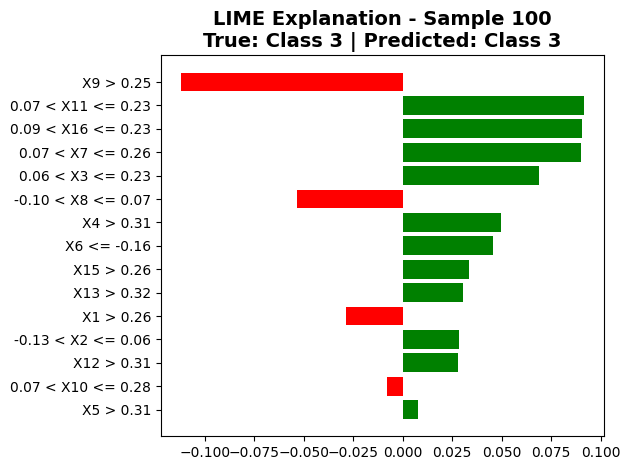

✅ Plot shown + HTML saved as 'lime_explanation_sample_100.html'


In [ ]:
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt
import pandas as pd

best_model = models['LightGBM']

# Create LIME Explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Healthy (0)', 'Generalized (1)', 'Focal (2)', 'Seizure Events (3)'],
    mode='classification',
    discretize_continuous=True,
    random_state=42
)

print("LIME Explainer Ready!\n")

# ====================== GENERATE LIME FOR 5 SAMPLES ======================
samples_to_explain = [0, 10, 25, 50, 100]   # You can change these indices

for idx in samples_to_explain:
    instance = X_test.iloc[idx].values
    true_label = int(y_test.iloc[idx])
    pred_label = int(best_model.predict([instance])[0])

    print(f"\n{'='*70}")
    print(f"Sample {idx} → True Label: {true_label} | Predicted: {pred_label}")
    print(f"{'='*70}")

    # Generate explanation
    exp = explainer.explain_instance(
        data_row=instance,
        predict_fn=best_model.predict_proba,
        num_features=15,
        labels=[0,1,2,3]
    )

    # ==================== PLOT (Fixed) ====================
    try:
        plt.figure(figsize=(16, 9))
        # Use the predicted label safely
        exp.as_pyplot_figure(label=pred_label)
        plt.title(f"LIME Explanation - Sample {idx}\nTrue: Class {true_label} | Predicted: Class {pred_label}",
                  fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

        # Save as HTML (Interactive)
        exp.save_to_file(f'lime_explanation_sample_{idx}.html')
        print(f"✅ Plot shown + HTML saved as 'lime_explanation_sample_{idx}.html'")

    except Exception as e:
        print(f"Plot error for sample {idx}: {e}")
        # Fallback: Show text explanation
        print(exp.as_list(label=pred_label))